<a href="https://colab.research.google.com/github/Zeeshan-3050/Data-analyst-/blob/main/diamonds%20big%20dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Loading Big Datasets for Analysis

When working with large datasets in Colab, it's common to store them in cloud storage or use a data warehouse. Here are a few common approaches:

1.  **Google Cloud Storage (GCS):** For files (CSV, Parquet, JSON, etc.), GCS is a scalable and cost-effective object storage service. You can load data directly from GCS into pandas DataFrames or other data structures.
2.  **BigQuery:** For extremely large, structured datasets, BigQuery is Google Cloud's fully managed, serverless data warehouse. It allows you to run SQL queries over terabytes of data quickly without managing infrastructure.
3.  **Local files (not recommended for 'big' data):** While you can upload files directly to the Colab environment, this is generally not suitable for truly "big" datasets due to upload limits and temporary storage.

### Example: Loading a CSV from GCS using pandas

To load data from GCS, you typically need to authenticate your Colab environment to access your GCP project. The `pandas-gbq` library simplifies this process. You'll need to enable the BigQuery API for your project, even if you're just using GCS for CSVs, as `pandas-gbq` provides convenient authentication.

First, make sure you have the necessary library installed:

In [ ]:
# Install the pandas-gbq library if you haven't already
# !pip install pandas-gbq google-cloud-storage


In [ ]:
import seaborn as sns
import pandas as pd

# Load the diamonds dataset
df_diamonds = sns.load_dataset('diamonds')

print("Successfully loaded the diamonds dataset!")
display(df_diamonds.head())
display(df_diamonds.info())


Successfully loaded the diamonds dataset!


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


None

## Data Cleaning and Preparation

In [ ]:
# Check for missing values
print("Missing values in each column:")
display(df_diamonds.isnull().sum())

# Display descriptive statistics for numerical columns
print("\nDescriptive statistics for numerical columns:")
display(df_diamonds.describe())

# Display value counts for categorical columns
print("\nValue counts for categorical columns:")
for col in ['cut', 'color', 'clarity']:
    print(f"\n--- {col} ---")
    display(df_diamonds[col].value_counts())


Missing values in each column:


,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0



Descriptive statistics for numerical columns:


,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000



Value counts for categorical columns:

--- cut ---


,count
cut,
Ideal,21551
Premium,13791
Very Good,12082
Good,4906
Fair,1610



--- color ---


,count
color,
G,11292
E,9797
F,9542
H,8304
D,6775
I,5422
J,2808



--- clarity ---


,count
clarity,
SI1,13065
VS2,12258
SI2,9194
VS1,8171
VVS2,5066
VVS1,3655
IF,1790
I1,741


### Saving the Processed Data to CSV

After the initial cleaning and inspection, we can save the `df_diamonds` DataFrame to a CSV file for future use or sharing.

In [7]:
processed_data_path = 'processed_diamonds.csv'
df_diamonds.to_csv(processed_data_path, index=False)
print(f"Processed dataset saved to '{processed_data_path}'")

Processed dataset saved to 'processed_diamonds.csv'


## Data Analysis and Dashboard Creation

Now that we've performed initial data cleaning and inspection, let's create a dashboard to visualize the dataset's key features and relationships.

/tmp/ipykernel_11761/340632237.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cut', y='price', data=df_diamonds, ax=axes[1, 0], palette='coolwarm')
/tmp/ipykernel_11761/340632237.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='color', y='price', data=df_diamonds, ax=axes[1, 1], palette='plasma')


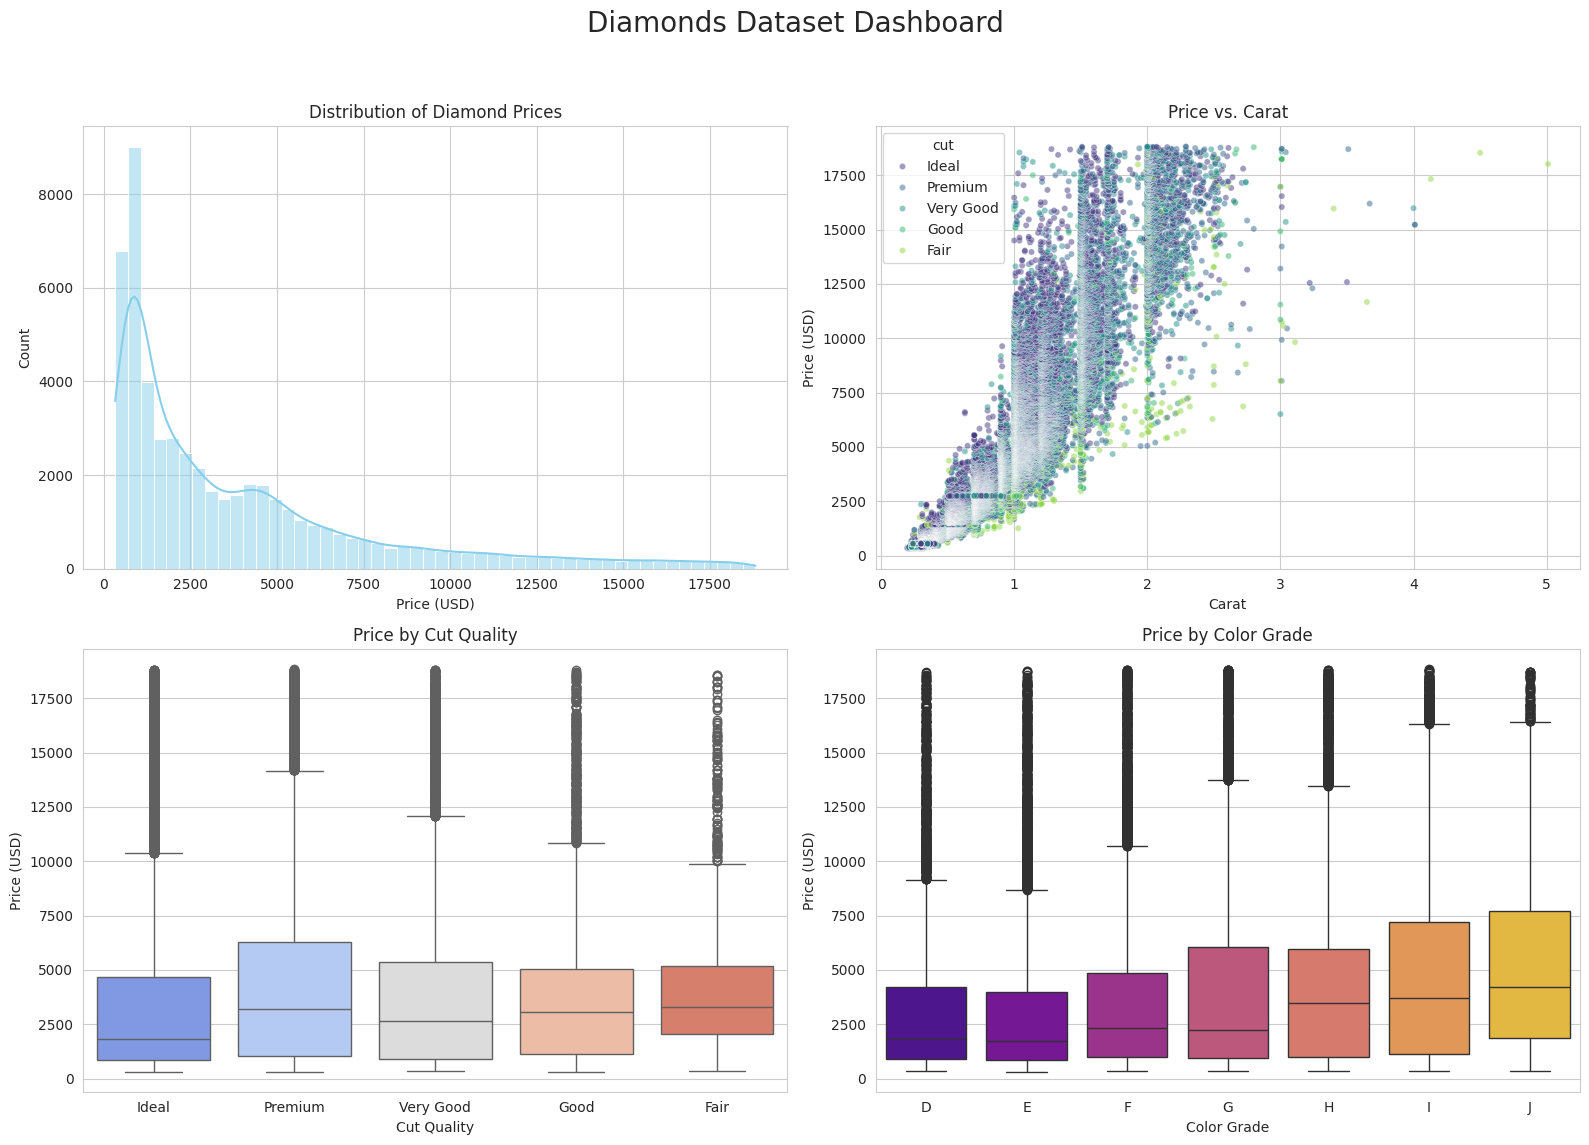

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
fig.suptitle('Diamonds Dataset Dashboard', fontsize=20)

# Plot 1: Distribution of Price
sns.histplot(df_diamonds['price'], bins=50, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribution of Diamond Prices')
axes[0, 0].set_xlabel('Price (USD)')
axes[0, 0].set_ylabel('Count')

# Plot 2: Carat vs Price (Scatter Plot)
sns.scatterplot(x='carat', y='price', data=df_diamonds, ax=axes[0, 1], alpha=0.5, hue='cut', palette='viridis', s=20)
axes[0, 1].set_title('Price vs. Carat')
axes[0, 1].set_xlabel('Carat')
axes[0, 1].set_ylabel('Price (USD)')

# Plot 3: Price by Cut (Box Plot)
sns.boxplot(x='cut', y='price', data=df_diamonds, ax=axes[1, 0], palette='coolwarm', hue='cut', legend=False)
axes[1, 0].set_title('Price by Cut Quality')
axes[1, 0].set_xlabel('Cut Quality')
axes[1, 0].set_ylabel('Price (USD)')

# Plot 4: Price by Color (Box Plot)
sns.boxplot(x='color', y='price', data=df_diamonds, ax=axes[1, 1], palette='plasma', hue='color', legend=False)
axes[1, 1].set_title('Price by Color Grade')
axes[1, 1].set_xlabel('Color Grade')
axes[1, 1].set_ylabel('Price (USD)')

# Adjust layout to prevent overlapping titles and labels
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### Saving the Dashboard

To provide the dashboard as a file, we can save the generated Matplotlib figure as an image (e.g., PNG).

In [8]:
dashboard_image_path = 'diamonds_dashboard.png'
fig.savefig(dashboard_image_path, dpi=300, bbox_inches='tight')
print(f"Dashboard saved to '{dashboard_image_path}'")

Dashboard saved to 'diamonds_dashboard.png'
